# PDF → RDA DMP JSON: run a prompt version, score it, compare versions

The text of one DMP PDF plus the complete **maDMP 1.2** schema go to three models.
What comes back is scored against the form a person filled in by hand from the same
PDF. Every prompt version is saved under its own name, so you can see what a change
to the prompt did.

**To try a new prompt:** edit Step 3, give it a new `RUN_NAME` in the settings cell,
run all cells. Step 7 shows the new version next to every earlier one.

Running again with an existing name does not call the models again — the saved results
are loaded and re-scored. If the prompt was changed but the name was not, Step 3 stops
and asks for a new name, so no version is ever overwritten.

| Step | What happens |
|---|---|
| 1 | Read sample 14 with pdfplumber |
| 2 | Load the schema — unchanged |
| 3 | The prompt — the only thing to edit between versions |
| 4 | Run the three models |
| 5 | Score this version: correct, hallucinated, missed; precision, recall, F1 |
| 6 | Every field, model by model |
| 7 | Compare every saved version |

**The marks.** Every field a model wrote is **Correct** (matches the person's value, or both
blank) or **Hallucinated** (wrong, made up, or blank where the person had a value). A field the
person filled in that the model never got right is **Missed**. Precision is the share of what
the model wrote that was right; recall is the share of the document's fields it found; F1
balances the two. Identifiers must match exactly (ignoring `https://` and case), dates by
day, a licence by name or URL, and free text counts when at least three-quarters of the
model's words appear in the person's version. The rules are in `dmpbridge/rda/score.py`.


In [1]:
from pathlib import Path

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

from dmpbridge.extractors import get_extractor
from dmpbridge.rda import Version, load_schema
from dmpbridge.rda import report

RUN_NAME = "v2"                      # change this every time you change the prompt

SAMPLE    = 14
PDF       = Path("data/input/pdfs") / f"sample{SAMPLE}.pdf"
SCHEMA    = Path("data/output/rda/maDMP-schema-1.2.json")
REFERENCE = Path("data/output/rda") / f"RDA_DMP_sample{SAMPLE}_manual_annotation.json"
RUNS_DIR  = Path("data/output/rda/runs")

MODEL_1 = "llama3.1:8b"
MODEL_2 = "gemma4:e4b"
MODEL_3 = "llama3.3:70b"
MODELS  = [MODEL_1, MODEL_2, MODEL_3]

version = Version(RUN_NAME, sample=SAMPLE, models=MODELS, runs_dir=RUNS_DIR, num_ctx=32768, max_tokens=8000)


version 'v2': already saved - results will be loaded
saved versions: v1, v2


## Step 1 — Read the PDF


In [2]:
dmp_text = get_extractor("pdfplumber").extract(PDF)[0]["text"]
print(f"sample{SAMPLE}: {len(dmp_text):,} characters")
print(dmp_text[:300])


sample14: 12,930 characters
** Plan Overview **
_ A Data Management Plan created using DMPTool _
** DMP ID: ** https://doi.org/10.48321/D1CW23
** Title: ** Hakai Institute Juvenile Salmon Program Time Series
** Creator: ** Brett Johnson - ** ORCID: ** ++ 0000-0001-9317-0364 ++
** Affiliation: ** Hakai Institute
** Principal In


## Step 2 — Load the schema

The schema is used exactly as published — nothing removed, nothing changed. Its `$ref`
pointers are resolved so the model sees every definition in place.


In [3]:
schema, schema_text, n_defs = load_schema(SCHEMA)
print(f"{len(schema_text):,} characters of schema, {n_defs} definitions resolved")


37,332 characters of schema, 48 definitions resolved


## Step 3 — The prompt

**This is the cell to edit.** The schema is given to the model twice: as text in the
prompt, and as Ollama's `format`, which constrains the JSON it generates to that
structure. The exact prompt is saved as `prompt.txt` in the version's folder.


In [4]:
SYSTEM = """You convert Data Management Plans into RDA maDMP JSON.

Strict rules:
1. Use only the field names defined in the schema. Never add a key that is not in the schema.
2. Put every field exactly where the schema places it. The whole document is one top-level "dmp" object.
3. Where the schema lists allowed values, use one of them, spelled exactly as in the schema .
4. Take every value from the Data Management Plan text. Never copy example values from the schema and never hallucinate.
5. Output only the JSON object. No explanation, no markdown.
6. Include every dataset, contributor, funder, host and distribution the text mentions. Leave out any field the text gives no information for."""


def make_prompt(dmp_text):
    return f"""Here is the RDA maDMP JSON schema (version 1.2). Follow it strictly:

{schema_text}

Here is the text of a Data Management Plan:

{dmp_text}

Generate one JSON object that strictly follows the schema above, filling in
whatever information the Data Management Plan text contains. Output only the JSON."""


version.set_prompt(SYSTEM, make_prompt, schema, schema_text)
print(f"{len(make_prompt(dmp_text)):,} characters go to the model: the system text, the schema and the document")


prompt saved -> data\output\rda\runs\v2\prompt.txt
50,539 characters go to the model: the system text, the schema and the document


## Step 4 — Run the three models

One model at a time: it is loaded, checked to be **100% on the GPU** (a model spilling
onto the CPU turns seconds into hours and is skipped), then called with the prompt. Each
result is saved as soon as it arrives, with the time taken and the tokens in and out.
A model that never finishes a valid JSON (it looped until the token cap) is recorded as
failed for this version, and what it wrote is kept in a `.raw.txt` file.

The 70B needs about 53 GB of VRAM at this context size — all three 24 GB cards. With
fewer cards available it cannot sit fully on the GPU and is skipped.


In [5]:
version.run(MODEL_1, dmp_text)


llama3.1:8b: already failed for version 'v2' - no valid JSON - it stopped at the 8,000-token cap, so it never finished
(delete sample14.rda.llama3.1-8b.raw.txt in the version's folder to try it again)


In [6]:
version.run(MODEL_2, dmp_text)


gemma4:e4b: already saved for version 'v2', loaded from data\output\rda\runs\v2\sample14.rda.gemma4-e4b.json
(that run took 26 s, 12,736 tokens sent, 2,725 generated)

{
  "dmp": {
    "contact": {
      "contact_id": {
        "identifier": "++",
        "type": "orcid"
      },
      "mbox": "N/A",
      "name": "Brett Johnson"
    },
    "created": "2015-05-12T00:00:00Z",
    "dataset": [
      {
        "dataset_id": {
          "identifier": "www.github.com/hakaiinstitute/jsp-data",
          "type": "url"
        },
        "personal_data": "unknown",
        "sensitive_data": "unknown",
        "title": "Hakai JSP Time Series",
        "description": "The core of the Hakai JSP are the observations made at sea during seining operations, and the observations and measurements made in the lab during fish dissections. Many samples are produced from fish that are collected in the lab, and those data may be addressed in their own Data Management Plans. Data from the field and lab disse

In [7]:
version.run(MODEL_3, dmp_text)


llama3.3:70b: SKIPPED - not fully on the GPU (ollama ps says: not loaded)


## Step 5 — Score this version

Each model's JSON is compared field by field with the reference. One row per model:
*fields in reference* is how many fields the person filled in, *fields output* how many
the model wrote.


In [8]:
summary, details = version.score(REFERENCE)
display(summary)
report.worked_example(summary)


not scored: llama3.1:8b - no valid JSON - it stopped at the 8,000-token cap, so it never finished
not scored: llama3.3:70b - not fully on the GPU (ollama ps says: not loaded)
version 'v2', sample14: the person filled in 135 fields
saved -> data\output\rda\runs\v2\scores.json, details.csv and evaluation_results.xlsx


,fields in reference,fields output,correct,hallucinated,missed,precision,recall,f1
model,,,,,,,,
gemma4:e4b,135,136,51,85,95,0.375,0.296,0.331


Worked example, gemma4:e4b:
  precision = correct / fields output          = 51 / 136 = 0.375
  recall    = (reference - missed) / reference = (135 - 95) / 135 = 0.296
  F1        = 2 * precision * recall / (precision + recall) = 0.331


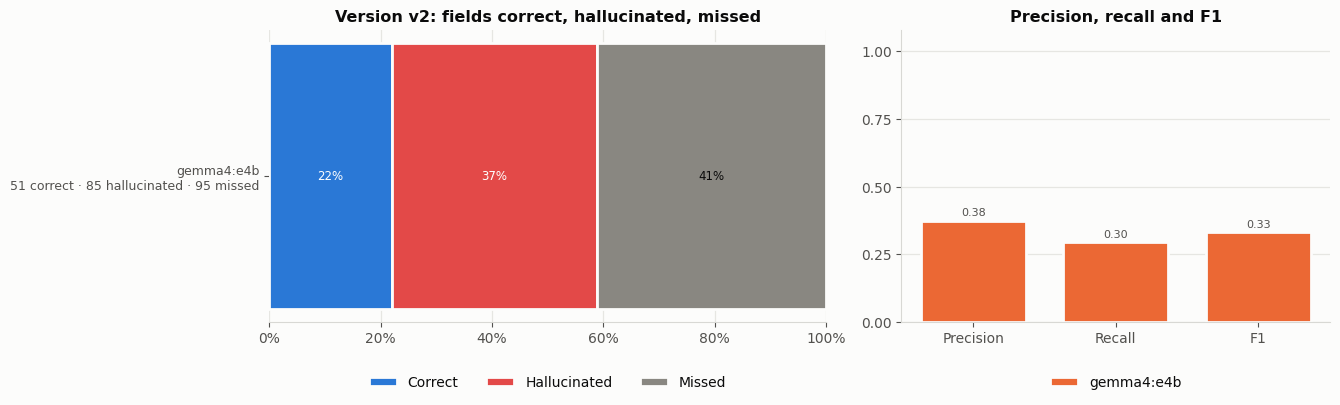

In [9]:
report.plot_version(summary, MODELS, title=f"Version {RUN_NAME}", save_to=version.dir / "evaluation_charts.png")


## Step 6 — Every field, model by model

What each model wrote next to what the person wrote, with the mark and the reason.
Hallucinated rows come first so the problems are at the top. Missed fields are listed
in the Excel file saved with the version.


In [10]:
report.show_fields(details, MODELS)



gemma4:e4b: 51 correct, 85 hallucinated, 95 missed


,field,model value,reference value,verdict,reason
0,dmp.contact.contact_id[0].identifier,++,0000-0001-9317-0364,Hallucinated,identifier differs
1,dmp.dataset[0].dataset_id.identifier,www.github.com/hakaiinstitute/jsp-data,https://doi.org/10.21966/1.566666,Hallucinated,identifier differs
2,dmp.dataset[0].dataset_id.type,url,doi,Hallucinated,different value
3,dmp.dataset[0].description,The core of the Hakai JSP are the observations made at sea during ...,The core of the Hakai JSP are the observations made at sea during ...,Hallucinated,only 33% of the model's words are in the reference
4,dmp.dataset[0].metadata[0].metadata_standard_id[0].identifier,http://www.iana.org/assignments/media-types/media-types.xhtml,None,Hallucinated,not in the reference
...,...,...,...,...,...
131,dmp.dmp_id.type,doi,doi,Correct,
132,dmp.ethical_issues_exist,no,no,Correct,
133,dmp.language,eng,eng,Correct,
134,dmp.project[0].start,2015-05-12,2015-05-12,Correct,


## Step 7 — Compare every saved version

Every scored version under `data/output/rda/runs/`, oldest first: the scores per version
and model, F1 and recall as lines, then what changed field by field between this version
and the one before it, and the change made to the prompt.


versions, oldest first: v1, v2


correct  hallucinated  missed  precision  recall     f1
version model                                                               
v1      llama3.1:8b       15             2     120      0.882   0.111  0.197
        gemma4:e4b         8            13     127      0.381   0.059  0.103
v2      gemma4:e4b        51            85      95      0.375   0.296  0.331


F1 per version and model:


model,llama3.1:8b,gemma4:e4b
version,,
v1,0.197,0.103
v2,NaN,0.331


v1: no score for llama3.3:70b - not fully on the GPU (ollama ps says: not loaded)
v2: no score for llama3.1:8b - no valid JSON - it stopped at the 8,000-token cap, so it never finished
v2: no score for llama3.3:70b - not fully on the GPU (ollama ps says: not loaded)


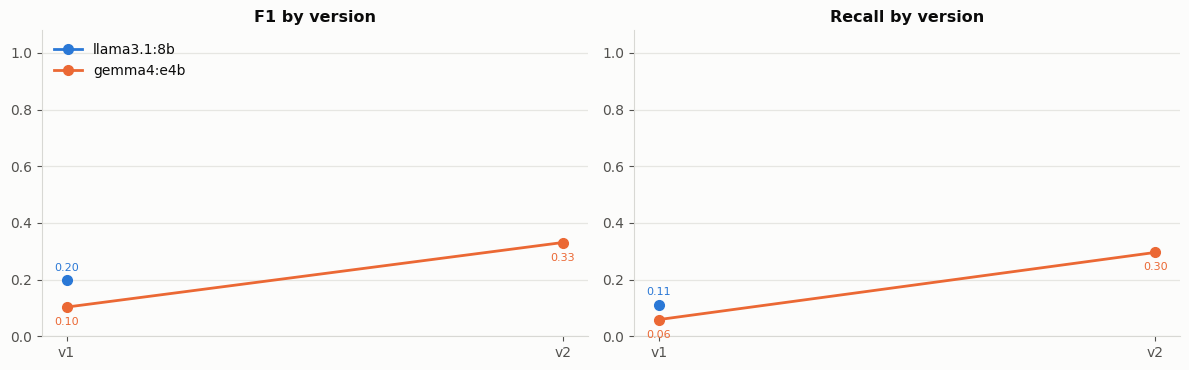

In [11]:
history = report.load_history(RUNS_DIR)
report.show_history(history, MODELS)
report.plot_history(history, MODELS, save_to=RUNS_DIR / "versions.png")


In [12]:
report.show_changes(version, history, summary, details)


What changed from 'v1' to 'v2'

gemma4:e4b: F1 0.103 -> 0.331   correct 8 -> 51, hallucinated 13 -> 85, missed 127 -> 95
   now right, was not before:   44   dmp.contact.mbox, dmp.contact.name, dmp.ethical_issues_exist, dmp.dataset[0].metadata[0].language, dmp.dataset[10].description, dmp.dataset[10].metadata[0].language, ... and 38 more
   was right, now not:           1   dmp.dataset[0].dataset_id.type
   wrong both times, differently (missed before and a wrong value now, or the reverse): 74
   The full list is in details.csv in each version's folder.

Prompt change:

--- v1
+++ v2
@@ -9,2 +9,3 @@
 5. Output only the JSON object. No explanation, no markdown.
+6. Include every dataset, contributor, funder, host and distribution the text mentions. Leave out any field the text gives no information for.
 
